In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

# Task 1

In [2]:
df = pd.read_csv("dataset/indian_ecommerce_dataset.csv")

In [3]:
df.head()

,Product_ID,Product_Name,Category,Brand,Price,Rating,Description,Seller,City,State,Stock_Quantity,Discount_Percentage
0,P00001,Boat Electronic Model 509,Electronics,Boat,72396,3.5,Boat electronics product with premium features.,Seller_72,Mumbai,West Bengal,379,69
1,P00002,Apple Mobile Model 7012,Mobiles,Apple,8630,3.1,Apple mobiles product with premium features.,Seller_112,Bengaluru,Tamil Nadu,308,3
2,P00003,Samsung Home Appliance Model 9028,Home Appliances,Samsung,110273,3.4,Samsung home appliances product with premium f...,Seller_302,Hyderabad,Gujarat,445,0
3,P00004,Asus Laptop Model 5674,Laptops,Asus,73141,3.3,Asus laptops product with premium features.,Seller_491,Chennai,Maharashtra,47,48
4,P00005,Realme Mobile Model 5735,Mobiles,Realme,69641,4.6,Realme mobiles product with premium features.,Seller_374,Ahmedabad,Tamil Nadu,63,48


# Task 2 - Data Cleaning

In [4]:
# Checking null values
df.isnull().sum()

Product_ID             0
Product_Name           0
Category               0
Brand                  0
Price                  0
Rating                 0
Description            0
Seller                 0
City                   0
State                  0
Stock_Quantity         0
Discount_Percentage    0
dtype: int64

In [5]:
# Checking duplicate records
len(df[df.duplicated() == True])

0

In [6]:
# Checking data types
df.dtypes

Product_ID              object
Product_Name            object
Category                object
Brand                   object
Price                    int64
Rating                 float64
Description             object
Seller                  object
City                    object
State                   object
Stock_Quantity           int64
Discount_Percentage      int64
dtype: object

# Task 3 - Exploratory Data Analysis

In [7]:
# Total number of products
df.columns
print("Total number of products in the dataset: ", df['Product_ID'].count())
print("Total number of distinct products in the dataset: ", len(df['Product_Name'].unique()))

Total number of products in the dataset:  20000
Total number of distinct products in the dataset:  19298


In [8]:
# Total number of categories
print("All categories for the products:", df['Category'].unique())
print("Total number of categories: ", len(df['Category'].unique()))

All categories for the products: ['Electronics' 'Mobiles' 'Home Appliances' 'Laptops' 'Clothing' 'Footwear']
Total number of categories:  6


We will find the top 10 brands on the basis of rating.
First finding how many distinct brands are present.
Then understanding how many ratings each brand has.
We can caculate average rating for all brands and then sorting them in a descendant manner.

In [9]:
# Top 10 brands
print("All brands present in our dataset: ", df['Brand'].unique())
print("Number of ratings: ", df['Rating'].groupby(df['Brand']).count())

All brands present in our dataset:  ['Boat' 'Apple' 'Samsung' 'Asus' 'Realme' 'Puma' 'Lenovo' 'Sony' 'Acer'
 'Philips' 'LG' 'Nike' 'Vivo' 'Wrogn' 'Adidas' 'HP' 'Allen Solly'
 'Whirlpool' 'JBL' 'Levis' 'Dell' 'Bata' 'OnePlus' 'Roadster' 'Xiaomi'
 'Noise']
Number of ratings:  Brand
Acer            680
Adidas          855
Allen Solly     672
Apple           571
Asus            663
Bata            823
Boat            776
Dell            681
HP              657
JBL             766
LG              841
Lenovo          682
Levis           685
Nike            850
Noise           827
OnePlus         606
Philips         757
Puma           1525
Realme          540
Roadster        675
Samsung        1406
Sony            798
Vivo            601
Whirlpool       829
Wrogn           657
Xiaomi          577
Name: Rating, dtype: int64


In [10]:
avg_rating = df['Rating'].groupby(df['Brand']).mean()

In [11]:
## Sorting the avg 
avg_rating = avg_rating.sort_values(ascending=False)

In [12]:
print("Top 10 Brands on the basis of ratings are: \n", avg_rating.head(10))

Top 10 Brands on the basis of ratings are: 
 Brand
Noise        4.034946
Roadster     4.026667
Sony         4.026566
Realme       4.024074
Philips      4.023250
Whirlpool    4.012907
Samsung      4.008677
Apple        4.007180
Adidas       4.006199
LG           4.005945
Name: Rating, dtype: float64


In [13]:
# Average Product Price
avg_price = df.groupby('Category')['Price'].mean()
print("Average price across all categories:\n", avg_price)

Average price across all categories:
 Category
Clothing           76749.566677
Electronics        74724.176508
Footwear           73764.368000
Home Appliances    75560.968069
Laptops            74738.333928
Mobiles            74760.865745
Name: Price, dtype: float64


In [14]:
# Highest rated products
highest_rated_products = df.groupby('Product_Name')['Rating'].mean().sort_values(ascending=False)

In [15]:
print("Highest rated products are: \n",highest_rated_products.head(10))

Highest rated products are: 
 Product_Name
Xiaomi Mobile Model 9517     5.0
Dell Laptop Model 5645       5.0
Dell Laptop Model 5987       5.0
Samsung Mobile Model 3853    5.0
Adidas Footwea Model 9374    5.0
Samsung Mobile Model 1482    5.0
Adidas Footwea Model 8499    5.0
Dell Laptop Model 4451       5.0
Dell Laptop Model 926        5.0
Dell Laptop Model 9146       5.0
Name: Rating, dtype: float64


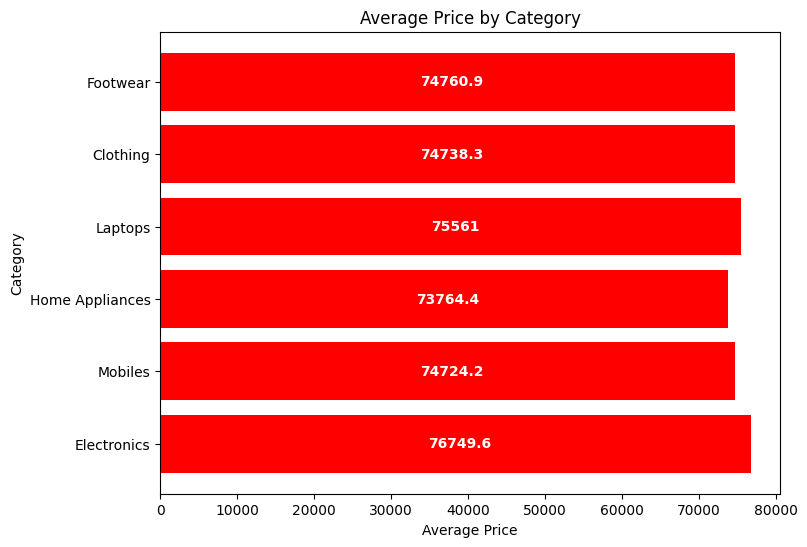

In [16]:
# Bar Chart - for average price across all products
avg_price = df.groupby('Category')['Price'].mean()
plt.figure(figsize=(8,6))
bars = plt.barh(df['Category'].unique(), avg_price, color='red')
plt.title('Average Price by Category')
plt.xlabel('Average Price')
plt.ylabel('Category')
plt.bar_label(bars, padding = 3, label_type='center', color='white', fontweight='bold')
plt.savefig('charts/avg_category_price.png', bbox_inches='tight')
plt.show()

In [17]:
# Pie Chart - Stock quantity according to state
state_stock_quantity = df.groupby('State')['Stock_Quantity'].sum()
state_stock_quantity.values

array([710657, 699817, 735878, 736091, 688845, 699913, 712104])

In [18]:
list(df['State'].unique())

['West Bengal',
 'Tamil Nadu',
 'Gujarat',
 'Maharashtra',
 'Delhi',
 'Telangana',
 'Karnataka']

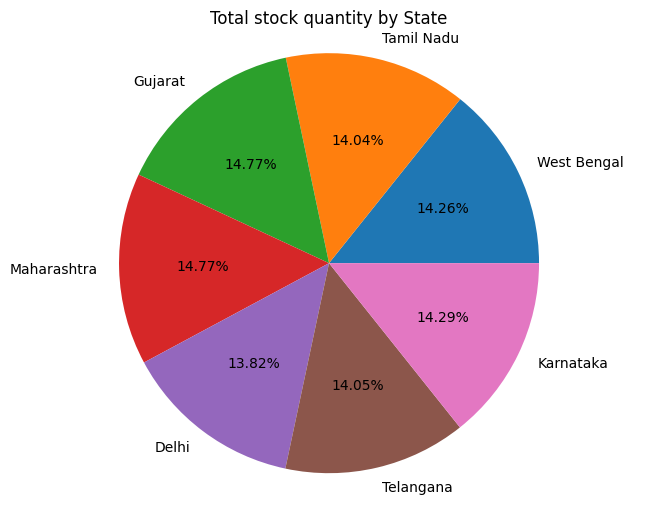

In [19]:
plt.figure(figsize=(8,6))
plt.pie(list(state_stock_quantity.values), labels=list(df['State'].unique()), autopct='%1.2f%%')
plt.title("Total stock quantity by State")
plt.axis('equal')
plt.savefig('charts/stock_quantity_by_state.png')
plt.show()

In [20]:
avg_rating_seller = df['Rating'].groupby(df['Seller']).mean()

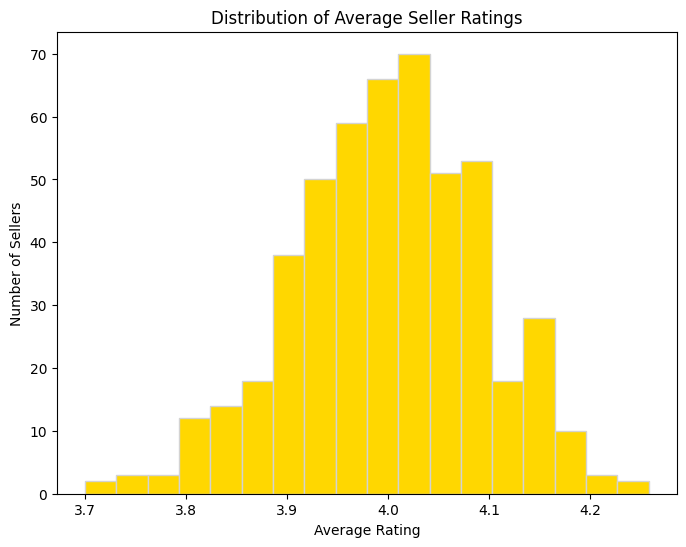

In [21]:
# Histogram - Average rating for all Sellers
plt.figure(figsize=(8,6))
plt.hist(avg_rating_seller.values, bins=18, color='gold', edgecolor='lightgray')
plt.title("Distribution of Average Seller Ratings")
plt.xlabel('Average Rating')
plt.ylabel('Number of Sellers')
plt.savefig("charts/average_ratings_dist.png")
plt.show()

# Task 4 - Feature Engineering

In [22]:
# Creating new column named Features
df['Features'] = df['Category'] + ',' + df['Brand'] + ',' + df['Description']

In [23]:
print("Printing first few values for the new column: \n")
df.head(1)

Printing first few values for the new column: 



,Product_ID,Product_Name,Category,Brand,Price,Rating,Description,Seller,City,State,Stock_Quantity,Discount_Percentage,Features
0,P00001,Boat Electronic Model 509,Electronics,Boat,72396,3.5,Boat electronics product with premium features.,Seller_72,Mumbai,West Bengal,379,69,"Electronics,Boat,Boat electronics product with..."


In [24]:
df.to_csv("dataset/feature_engineered_ecommerce.csv", index=False)

# Task 5 - Text Vectorization

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

In [26]:
tfidf_matrix = tfidf.fit_transform(df['Features'])
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 103929 stored elements and shape (20000, 37)>
  Coords	Values
  (0, 10)	0.5483230244085471
  (0, 7)	0.8194126780351004
  (0, 26)	0.09644467149409001
  (0, 25)	0.09644467149409001
  (0, 11)	0.09644467149409001
  (1, 26)	0.09275044328084815
  (1, 25)	0.09275044328084815
  (1, 11)	0.09275044328084815
  (1, 20)	0.5103224876832125
  (1, 3)	0.8448449706179448
  (2, 26)	0.09136510119818385
  (2, 25)	0.09136510119818385
  (2, 11)	0.09136510119818385
  (2, 13)	0.514324992581685
  (2, 4)	0.514324992581685
  (2, 30)	0.6677550889816086
  (3, 26)	0.09466128168483592
  (3, 25)	0.09466128168483592
  (3, 11)	0.09466128168483592
  (3, 16)	0.5268187206607413
  (3, 5)	0.834014244968713
  (4, 26)	0.09194614233718902
  (4, 25)	0.09194614233718902
  (4, 11)	0.09194614233718902
  (4, 20)	0.505897141087604
  :	:
  (19995, 10)	0.5507508613519856
  (19995, 26)	0.09687170433062596
  (19995, 25)	0.09687170433062596
  (19995, 11)	0.09687170433062596
  (

# Task 6 - Similarity Matrix

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

In [28]:
#Calculating cosine similarity between products
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(cosine_sim)

[[1.         0.02683586 0.02643503 ... 0.02705223 0.03137987 0.0270875 ]
 [0.02683586 1.         0.02542246 ... 0.28854484 0.03017789 0.28892105]
 [0.02643503 0.02542246 1.         ... 0.02562744 0.02972714 0.02566085]
 ...
 [0.02705223 0.28854484 0.02562744 ... 1.         0.0304212  0.29125056]
 [0.03137987 0.03017789 0.02972714 ... 0.0304212  1.         0.03046087]
 [0.0270875  0.28892105 0.02566085 ... 0.29125056 0.03046087 1.        ]]


In [29]:
len(cosine_sim)

20000

# Task 7 - Recommendation Function

In [85]:
df['Price'].max()

np.int64(149998)

In [81]:
# Creating the recommendation function
def recommend_products(product_name, min_price=0, max_price=0):
    idx = df[df['Product_Name'] == product_name].index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # sim_scores = sim_scores[1:6]
    if max_price:
        product_indices = [i for i,s in sim_scores if min_price <= df['Price'][i] <= max_price][:5]
    else:    
        product_indices = [x[0] for x in sim_scores][1:6]

    return df[['Product_Name','Category','Brand','Price','Rating']].iloc[product_indices]

# Task 8 - User Input

In [82]:
# Taking product name from the user
product = input("Enter product name: ")
price_filter = input("Do you want to apply price filter").lower()
if price_filter == 'yes':
    min_price = int(input("Enter min price: "))
    max_price = int(input("Enter max price: "))
    recommendations = recommend_products(product, min_price, max_price)
    
else:
    recommendations = recommend_products(product)
print(recommendations)

Enter product name:  Puma Footwea Model 3259
Do you want to apply price filter yes
Enter min price:  20000
Enter max price:  25000


                 Product_Name  Category Brand  Price  Rating
315   Puma Footwea Model 5811  Footwear  Puma  23101     3.9
637    Puma Footwea Model 687  Footwear  Puma  24711     4.5
1358  Puma Footwea Model 7137  Footwear  Puma  24694     3.4
1623  Puma Footwea Model 5666  Footwear  Puma  22583     4.8
1711  Puma Footwea Model 9008  Footwear  Puma  24429     3.2


# Task 9 - Exception Handling

In [87]:
try:
    product_name = input("Enter the product name:")
    if not product_name:
        raise ValueError("Product name cannot be empty.")
    elif product_name not in df['Product_Name'].values:
        raise ValueError("Product not found in the dataset.") 
    print(recommend_products(product_name))
except ValueError as e:
    print(f"Error: {e}")

Enter the product name: Philips Home Appliance Model 1589


                          Product_Name         Category    Brand   Price  \
24   Philips Home Appliance Model 2396  Home Appliances  Philips  110892   
38   Philips Home Appliance Model 9289  Home Appliances  Philips    2833   
146  Philips Home Appliance Model 6885  Home Appliances  Philips   71908   
151  Philips Home Appliance Model 6943  Home Appliances  Philips   76193   
195  Philips Home Appliance Model 9302  Home Appliances  Philips   31169   

     Rating  
24      3.4  
38      3.2  
146     3.4  
151     3.2  
195     3.5  
